# Homework 3: Bayesian Models and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to quantify uncertainties for a simple model
    using Bayesian statistics and rejection sampling.
-   Problem 2 asks you to use Monte Carlo simulation to calculate annual
    expected flooding damages.
-   Problem 3 (only required for students in BEE 5850) asks you to
    conduct cost-benefit analyses of housing elevation levels under
    future flooding uncertainty using Monte Carlo simulations.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
# import Pkg
# Pkg.activate(@__DIR__)
# Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
# using Random # random number generation and seed-setting
# using DataFrames # tabular data structure
# using CSV # reads/writes .csv files
# using Distributions # interface to work with probability distributions
# using Plots # plotting library
# using StatsBase # statistical quantities like mean, median, etc
# using StatsPlots # some additional statistical plotting tools
# using Optim # optimization tools

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.stats import pearsonr
from scipy.stats import bernoulli, beta, binom, lognorm, uniform
import math
from scipy.optimize import minimize
import random

## Problems

### Scoring

-   Problem 1 is worth 13 points.
-   Problem 2 is worth 7 points.
-   Problem 3 is worth 5 points.

### Problem 1

Consider the class-cheating testing procedure from [Homework
1](https://viveks.me/simulation-data-analysis/hw/hw01.html). As a
reminder, the procedure is as follows:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Suppose that, after conducting the procedure on your class of 100
students, you get 40 “Yes, I cheated” responses. You are skeptical that
your class is broadly engaged in cheating and have a prior belief that
the probability of cheating $\theta$ is unlikely to be high. We’ll
express this prior using a beta distribution, \$(3, 40), which is shown
below. You would like to understand the range of cheating propensity
which is consistent with your prior beliefs and the outcomes from the
detection procedure.

**In this problem**:

-   Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.
-   Plot the posterior $p(\theta | y)$ using a grid approximation
    (looping over values of $\theta$).
-   Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?
-   Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?
-   Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?


# Solution

In [4]:
def flip_ll(theta, reported_cheats):
    return binom.logpmf(reported_cheats, 100, 0.5*theta+0.25)

# flips = np.array(["H", "H", "H", "T", "H", "H", "H", "H", "H"])  # Example flip data
reported_cheats = 40
# result = minimize(lambda theta: -flip_ll(theta, reported_cheats), bounds=[(.001, 1)], x0=0.4)
# theta_mle = result.x[0]
# theta_mle_rounded = round(theta_mle, 5)
def flip_ll_prior(theta):
    return beta.logpdf(theta, 3, 40)

def flip_lposterior(theta, reported_cheats):
    return flip_ll(theta, reported_cheats) + flip_ll_prior(theta)

result = minimize(lambda theta: -flip_lposterior(theta, reported_cheats), bounds=[(0.01, 1)], x0=0.9)
theta_map = result.x[0]
theta_map_rounded = round(theta_map, 6)

In [19]:
theta_range = np.arange(0,1.005,0.01)
log_posterior = [flip_lposterior(theta_range[i], reported_cheats) for i in range(len(theta_range))]
log_prior = [flip_ll_prior(theta_range[i]) for i in range(len(theta_range))]
posterior = [math.exp(flip_lposterior(theta_range[i], reported_cheats)) for i in range(len(theta_range))]
prior = [math.exp(log_prior[i]) for i in range(len(theta_range))]

In [23]:
theta_map_rounded

np.float64(0.101229)

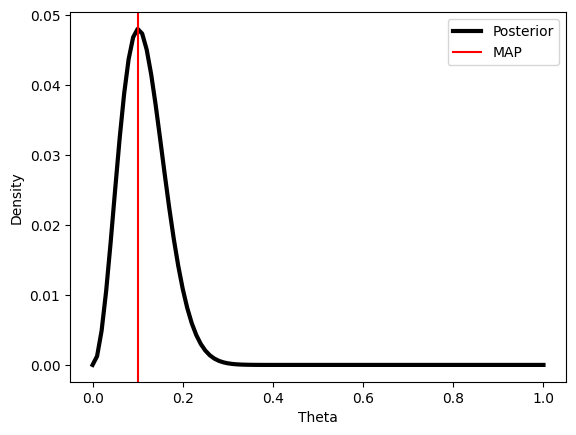

In [20]:
plt.plot(theta_range,posterior, color = 'black', label="Posterior", linewidth=3)
# plt.plot(theta_range,prior, color = 'blue', label="Prior", linewidth=3)
plt.axvline(x=theta_map_rounded, color='r')

plt.ylabel("Density")
plt.xlabel("Theta")
# plt.title("Posterior Distribution")
plt.legend(['Posterior','MAP'])

In [13]:

num_samples = 1000
keep_samp = np.zeros(num_samples)
# posterior = [math.exp(flip_lposterior(y[i], reported_cheats)) for i in range(len(y))]
num_kept = 0

rng = np.random.RandomState(10)
ys = uniform.rvs(0, 1, 100000, random_state = rng)
us = uniform.rvs(0, 1, 100000, random_state = rng)

i = 0
while (num_kept < num_samples-1):
        y = ys[i]
        u = us[i]
        M_u = 0.05*u
        posterior = math.exp(flip_lposterior(y, reported_cheats))
        if M_u < posterior:
            num_kept =  num_kept + 1
            keep_samp[num_kept] = y

        i = i+1

In [14]:
percent5 = np.percentile(keep_samp, 5)
percent95 = np.percentile(keep_samp, 95)

In [21]:
np.percentile(keep_samp, 50)

np.float64(0.10841672433805472)

In [26]:
from statistics import mode

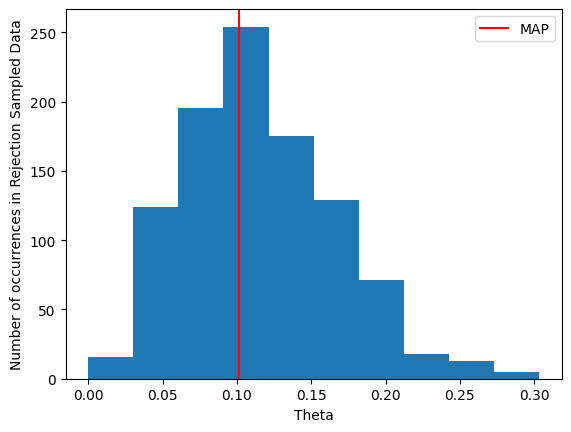

In [28]:
plt.hist(keep_samp, bins = 10)
plt.xlabel('Theta')
plt.ylabel('Number of occurrences in Rejection Sampled Data')
plt.axvline(x=theta_map_rounded, color='r', label = 'MAP')
plt.legend()

-   Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?

The approximation does capture the posterior reasonably well, with the highest density around 0.1 and limited density past 0.30. The mean of the sampled distribution is 10.8%, while the MAP value is 10.1%. There do not seem to be particular regions which are notably over or under represented by the sampling process. Although there are no samples past 0.35, this is consistent with the very low probability density for these regions. Thus, more samples may not be necessary to obtain a reasonable approximation of the posterior.

-   Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?

The 90% confidence interval is 3.98% to 20.3%. The mean is 10.8%. Thus, despite the constrained prior, this interval includes fairly high cheating rates, suggesting that they may actually be as high as 20%. It also appears unlikely that there is a cheating rate of 0%. The privacy-protecting procedure introduces considerable uncertainty, with the 90% credible interval containing a range of greater than 15%, between a fairly low value of 4% and a fairly high value of 20%.



Less constrained prior

In [32]:
# flips = np.array(["H", "H", "H", "T", "H", "H", "H", "H", "H"])  # Example flip data
reported_cheats = 40

def flip_ll_prior(theta):
    return beta.logpdf(theta, 5, 10)

def flip_lposterior(theta, reported_cheats):
    return flip_ll(theta, reported_cheats) + flip_ll_prior(theta)

result = minimize(lambda theta: -flip_lposterior(theta, reported_cheats), bounds=[(0.01, 1)], x0=0.9)
theta_map = result.x[0]
theta_map_rounded = round(theta_map, 6)

In [33]:
theta_range = np.arange(0,1.005,0.01)

In [49]:
log_posterior = [flip_lposterior(theta_range[i], reported_cheats) for i in range(len(theta_range))]
log_prior = [flip_ll_prior(theta_range[i]) for i in range(len(theta_range))]
posterior = [math.exp(flip_lposterior(theta_range[i], reported_cheats)) for i in range(len(theta_range))]
prior = [math.exp(log_prior[i]) for i in range(len(theta_range))]


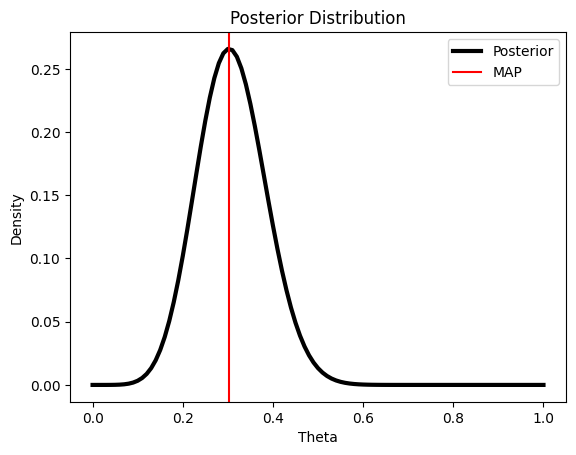

In [50]:
plt.plot(theta_range,posterior, color = 'black', label="Posterior", linewidth=3)
# plt.plot(theta_range,prior, color = 'blue', label="Prior", linewidth=3)
plt.axvline(x=theta_map_rounded, color='r')

plt.ylabel("Density")
plt.xlabel("Theta")
plt.title("Posterior Distribution")
plt.legend(['Posterior','MAP'])

In [46]:
num_samples = 1000
keep_samp = np.zeros(num_samples)
# posterior = [math.exp(flip_lposterior(y[i], reported_cheats)) for i in range(len(y))]
num_kept = 0

rng = np.random.RandomState(10)
ys = uniform.rvs(0, 1, 100000, random_state = rng)
us = uniform.rvs(0, 1, 100000, random_state = rng)

i = 0
while (num_kept < num_samples-1):
        y = ys[i]
        u = us[i]
        M_u = 0.05*u
        posterior_value = math.exp(flip_lposterior(y, reported_cheats))
        if M_u < posterior_value:
            num_kept =  num_kept + 1
            keep_samp[num_kept] = y

        i = i+1

In [47]:
percent5 = np.percentile(keep_samp, 5)
percent95 = np.percentile(keep_samp, 95)

In [48]:
percent95

np.float64(0.47947339067494155)

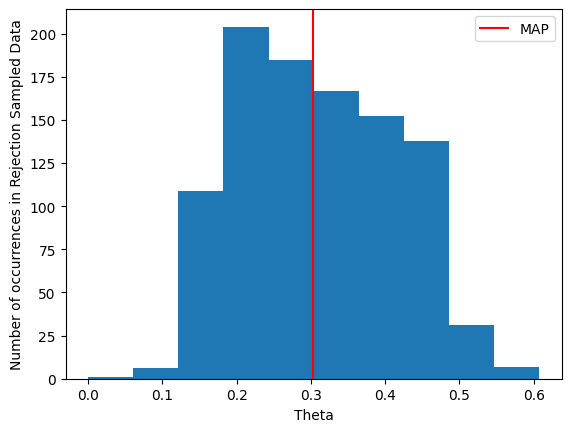

In [41]:
plt.hist(keep_samp, bins = 10)
plt.xlabel('Theta')
plt.ylabel('Number of occurrences in Rejection Sampled Data')
plt.axvline(x=theta_map_rounded, color='r', label = 'MAP')
plt.legend()

 Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?

This leads to a significant increase in the determined probability of cheating. The MAP value is now 30.3%, much higher than before. The 90% confidence interval goes from 15.8% to 47.9%. Thus, it would lead to the conclusion that the cheating rate is likely to be even higher. This suggests that the procedure is not very effective because the assumed prior is constraining the results. Therefore, unless we can have confidence in the prior distribution, it is difficult to know the accuracy of the result.

### Problem 2

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know the probability
distribution of annual flood damages to their home if they do not take
any preventative floodproofing measures. After some hydrologic analysis,
you have developed a 40-year record of annual maximum water levels (in
m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

# Solution

In [ ]:
def indicator_function(x):
    if (x>0):
        return 1
    else:
        return 0

In [ ]:
def damage(x,k,x0):
    return indicator_function(x)*(1/(1+np.exp(-k*(x-x0))))

In [ ]:
k = 1.25
x0 = 2
damage(3,k,x0)

np.float64(0.7772998611746911)

**In this problem**:

-   Fit a log-normal distribution to the water depth data by maximizing
    likelihood.
-   Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?



In [ ]:
data_dir = os.path.join("data", "water_depths.csv")
depth_data = pd.read_csv(data_dir)

In [ ]:
def depth_loglik(params, depth_data):
    s, scale  = params  # unpack parameter vector
    # y = sim_gmsl(S_0, gmta_data, response_time, a, b)
    ll = np.sum(lognorm.logpdf(depth_data, s=s, scale = scale))  # compute log-likelihood
    return ll

In [ ]:
lb = [0.001, 0.001,]
ub = [5.0, 100000.0]
p0 = [1.25,2]

optim_out = minimize(lambda params: -depth_loglik(params, depth_data), p0, bounds=list(zip(lb, ub)))
# result = minimize(lambda theta: -flip_lposterior(theta, reported_cheats), bounds=[(0.01, 1)], x0=0.9)
p_mle = np.round(optim_out.x)

print(p_mle)

[0. 1.]


(array([ 5., 10., 11.,  6.,  2.,  3.,  2.,  0.,  0.,  1.]),
 array([0.70206024, 0.86871496, 1.03536968, 1.20202441, 1.36867913,
        1.53533385, 1.70198857, 1.8686433 , 2.03529802, 2.20195274,
        2.36860746]),
 <BarContainer object of 10 artists>)

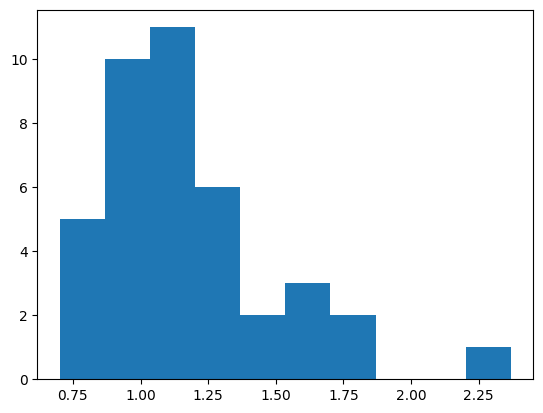

In [ ]:
plt.hist(depth_data)

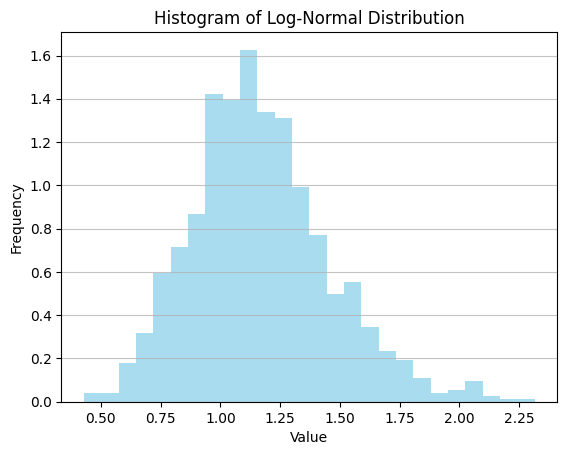

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Define parameters for the log-normal distribution
shape = optim_out.x[0]  # Shape parameter (sigma)
# mean = 0     # Mean of the underlying normal distribution (mu)
scale = optim_out.x[1] # Scale parameter, exp(mu)

# Generate random samples from the log-normal distribution
data = lognorm.rvs(shape, scale=scale, size=1000)

# Create the histogram
plt.hist(data, bins='auto', density=True, alpha=0.7, color='skyblue')

# Customize the plot
plt.title('Histogram of Log-Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Display the plot
plt.show()

In [ ]:
rng = np.random.RandomState(123)
nsamp = 10000
base_elevation = 1.5
depth = lognorm.rvs(s=optim_out.x[0], scale=optim_out.x[1], size=nsamp, random_state=rng)
x = depth - base_elevation
mc_results = [damage(x[i],k,x0) for i in range(nsamp)]

In [ ]:
mean = pd.Series(mc_results).mean()
se = pd.Series(mc_results).std()/np.sqrt(nsamp)
ci = 1.96*se

In [ ]:
np.mean(mc_results[:5])

np.float64(0.0)

C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value 

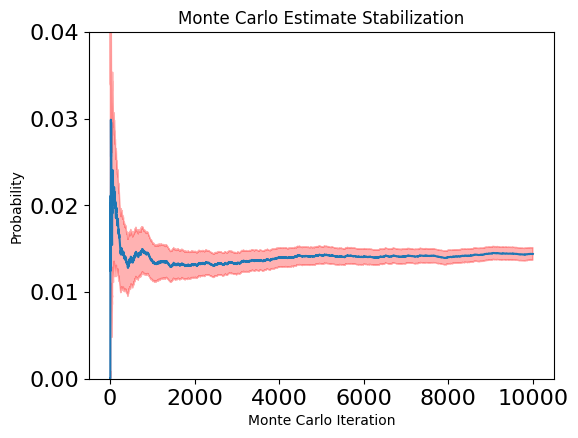

In [ ]:
running_estimate = np.zeros(nsamp)
std_mc_out = np.zeros(nsamp)
for i in range(nsamp):
    running_estimate[i] = np.mean(mc_results[:i])
    std_mc_out[i] = 1 / np.sqrt(i + 1) * np.std(mc_results[:i])

plt.figure(figsize=(6, 4.5))
plt.plot(running_estimate)
plt.xlabel("Monte Carlo Iteration")
plt.ylabel("Probability")
plt.fill_between(range(nsamp), running_estimate - 1.96 * std_mc_out, running_estimate + 1.96 * std_mc_out, color='red', alpha=0.3)
plt.tick_params(labelsize=16)
plt.title("Monte Carlo Estimate Stabilization")
plt.ylim(0, 0.04)
plt.show()

In [ ]:
home_value = 400000
mean_dam = home_value*mean
se_dam = home_value*se


In [ ]:
se_dam

np.float64(146.26315429566029)

The estimate is 1.44%, or $5,763.62, while the standard error is 0.037%, or $146.26. I would not use more samples because, based on the graph, the average seems to have stabilized and is not oscillating very much, so I would not expect for more samples to lead to significant changes to the mean. Also the standard error is relatively low. At this point, other uncertainties may dominate the results, such as uncertainties in the tide data itself, the approximation as a log-normal, and the ability of the depth-damage function to accurately capture the amount of damage incurred. 



### Problem 3

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

Next, your client would like advice on whether it would be
cost-effective to elevate their home to reduce flood risks. To address
this question, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.

> **Tip**
>
> Be careful about the quantity you’re estimating. Calculating the
> benefits of elevating by $\Delta h$ m requires calculating how the
> elevation *changes* the expected flooding damages over the design
> horizon *relative to a no-heightening baseline*.

**In this problem**:

-   Using the extreme water level distribution from Problem 2, use Monte
    Carlo simulation to estimate the NPV of the benefits of elevation
    levels between 0 and 5m (you don’t have to consider increments finer
    than 0.5m). What elevation heights pass the cost-benefit test? You
    can assume that the costs of elevation are all up front (that is, in
    year 0).
-   What height (including a possible elevation of 0m) maximizes the NPV
    of net benefits (benefits - ocsts)?[1]

[1] This is an example of **Monte Carlo optimization** as you are using
Monte Carlo simulation to estimate the optimization objective function.

In [ ]:
def npv(AV, discount, t):
    return AV*(1-discount)**t

In [ ]:
np.arange(0,5.5,0.5)

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

In [ ]:
npv_results = pd.Series(index = np.arange(0,5.5,0.5))

In [ ]:
npv_results.loc[0] = 1

In [ ]:
npv_base_dam = sum(npv(base_dam, discount, np.arange(horizon)))*home_value
npv_new_dam = sum(npv(new_dam, discount, np.arange(horizon)))*home_value

In [ ]:
depth = lognorm.rvs(s=optim_out.x[0], scale=optim_out.x[1], size=horizon, random_state=rng)
x_base = depth - baseline_elevation
x_new = depth - new_elevation
base_dam = [damage(x_base[i],k,x0) for i in range(horizon)]
new_dam = [damage(x_new[i],k,x0) for i in range(horizon)]
# reduce_dam = (pd.Series(base_dam) - pd.Series(new_dam))*home_value
# npv_net_benefit[i] = sum(pd.Series([reduce_dam[j]*(1-discount)**j for j in range(horizon)]))-cost
# running_estimate[i] = np.mean(npv_net_benefit[:i])
# std_mc_out[i] = 1 / np.sqrt(i + 1) * np.std(npv_net_benefit[:i])

In [ ]:
horizon = 30 # years
discount = 0.04
nsamp = 10000
npv_results = pd.Series(index = np.arange(0,5.5,0.5))
npv_benefit = pd.Series(index = np.arange(0,5.5,0.5))

for delta_h in np.arange(0,5.5,0.5):
    baseline_elevation = 1.5
    new_elevation = 1.5 + delta_h

    npv_net_benefit = np.zeros(nsamp)
    running_estimate = np.zeros(nsamp)
    std_mc_out = np.zeros(nsamp)

    cost = indicator_function(delta_h)*(100000+2000*delta_h)
    for i in range(nsamp):
        rng = np.random.RandomState(i)
        depth = lognorm.rvs(s=optim_out.x[0], scale=optim_out.x[1], size=horizon, random_state=rng)
        x_base = depth - baseline_elevation
        x_new = depth - new_elevation
        base_dam = [damage(x_base[i],k,x0) for i in range(horizon)]
        new_dam = [damage(x_new[i],k,x0) for i in range(horizon)]
        reduce_dam = (pd.Series(base_dam) - pd.Series(new_dam))*home_value
        npv_net_benefit[i] = sum(pd.Series([reduce_dam[j]*(1-discount)**j for j in range(horizon)]))-cost
        running_estimate[i] = np.mean(npv_net_benefit[:i])
        std_mc_out[i] = 1 / np.sqrt(i + 1) * np.std(npv_net_benefit[:i])
    
    npv_results.loc[delta_h] = np.mean(npv_net_benefit)
    npv_benefit.loc[delta_h] = np.mean(npv_net_benefit)+cost


C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value 

In [ ]:
horizon = 30 # years
discount = 0.04
nsamp = 10000
npv_results = pd.Series(index = np.arange(0,5.5,0.5))
npv_benefit = pd.Series(index = np.arange(0,5.5,0.5))


for delta_h in np.arange(0,5.5,0.5):
    baseline_elevation = 1.5
    new_elevation = 1.5 + delta_h

    npv_net_benefit = np.zeros(nsamp)
    running_estimate = np.zeros(nsamp)
    std_mc_out = np.zeros(nsamp)

    cost = indicator_function(delta_h)*(100000+2000*delta_h)
    for i in range(nsamp):
        rng = np.random.RandomState(i)
        depth = lognorm.rvs(s=optim_out.x[0], scale=optim_out.x[1], size=horizon, random_state=rng)
        x_base = depth - baseline_elevation
        x_new = depth - new_elevation
        base_dam = [damage(x_base[i],k,x0) for i in range(horizon)]
        new_dam = [damage(x_new[i],k,x0) for i in range(horizon)]
        npv_base_dam = sum(npv(base_dam, discount, np.arange(horizon)))*home_value
        npv_new_dam = sum(npv(new_dam, discount, np.arange(horizon)))*home_value
        npv_benefit[i] = npv_base_dam - npv_new_dam
        # npv_net_benefit[i] = npv_base_dam - npv_new_dam
        # running_estimate[i] = np.mean(npv_net_benefit[:i])
        # std_mc_out[i] = 1 / np.sqrt(i + 1) * np.std(npv_net_benefit[:i])
    
    # npv_results.loc[delta_h] = np.mean(npv_net_benefit)
    # npv_benefit.loc[delta_h] = np.mean(npv_net_benefit)+cost
    npv_results.loc[delta_h] = np.mean(npv_benefit)-cost


In [ ]:
np.mean(npv_benefit)

np.float64(101912.656359714)

In [ ]:
npv_results

0.0       0.000000
0.5   -8764.253322
1.0   -1254.113808
1.5   -1832.119864
2.0   -2498.427184
2.5   -3300.050912
3.0   -4811.189864
3.5   -5384.631756
4.0   -5874.691318
4.5   -7780.909268
5.0   -8087.343640
dtype: float64

In [ ]:
npv_base_dam - npv_new_dam

np.float64(156408.52377427535)

np.float64(0.0)

In [ ]:
np.mean(npv_net_benefit)+cost

np.float64(101261.91659772178)

In [ ]:
npv_base_dam - npv_new_dam

np.float64(156408.52377427535)

In [ ]:
np.mean(npv_net_benefit)+cost

In [ ]:
npv_benefit

0.0         0.000000
0.5     92200.061706
1.0    100574.522834
1.5    101201.749633
2.0    101256.858065
2.5    101261.916598
3.0    101261.916598
3.5    101261.916598
4.0    101261.916598
4.5    101261.916598
5.0    101261.916598
dtype: float64

None of the elevations pass the cost-benefit test, as all of an NPV of net benefits less than 0. Thus, 0 m is the height which maximizes the NPV of net benefits.

In [ ]:
horizon = 30 # years
discount = 0.04
nsamp = 10000
npv_results = pd.Series(index = np.arange(0,5.5,0.5))

delta_h = 0.5
baseline_elevation = 1.5
new_elevation = 1.5 + delta_h

npv_net_benefit = np.zeros(nsamp)
running_estimate = np.zeros(nsamp)
std_mc_out = np.zeros(nsamp)

cost = indicator_function(delta_h)*(100000+2000*delta_h)
for i in range(nsamp):
    rng = np.random.RandomState(i)
    depth = lognorm.rvs(s=optim_out.x[0], scale=optim_out.x[1], size=horizon, random_state=rng)
    x_base = depth - baseline_elevation
    x_new = depth - new_elevation
    base_dam = [damage(x_base[i],k,x0) for i in range(horizon)]
    new_dam = [damage(x_new[i],k,x0) for i in range(horizon)]
    reduce_dam = (pd.Series(base_dam) - pd.Series(new_dam))*home_value
    npv_net_benefit[i] = sum(pd.Series([reduce_dam[j]*(1-discount)**j for j in range(horizon)]))-cost
    running_estimate[i] = np.mean(npv_net_benefit[:i])
    std_mc_out[i] = 1 / np.sqrt(i + 1) * np.std(npv_net_benefit[:i])

npv_results.loc[delta_h] = np.mean(npv_net_benefit)


C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value 

In [ ]:
npv_benefit

0.0         0.000000
0.5     92200.061706
1.0    100574.522834
1.5    101201.749633
2.0    101256.858065
2.5    101261.916598
3.0    101261.916598
3.5    101261.916598
4.0    101261.916598
4.5    101261.916598
5.0    101261.916598
dtype: float64

In [ ]:
sum(pd.Series([reduce_dam[j]*(1-discount)**j for j in range(horizon)]))

101934.94114888011

In [ ]:
np.mean(npv_net_benefit)

np.float64(-8799.938293700874)

In [ ]:
i = 10
rng = np.random.RandomState(i)
depth = lognorm.rvs(s=optim_out.x[0], scale=optim_out.x[1], size=horizon, random_state=rng)
x_base = depth - baseline_elevation
x_new = depth - new_elevation
base_dam = [damage(x_base[i],k,x0) for i in range(horizon)]
new_dam = [damage(x_new[i],k,x0) for i in range(horizon)]
reduce_dam = (pd.Series(base_dam) - pd.Series(new_dam))*home_value
sum(pd.Series([reduce_dam[j]*(1-discount)**j for j in range(horizon)]))-cost


19119.737750781904

In [ ]:
reduce_dam.sum()

np.float64(234854.80316771136)

In [ ]:
cost

101000.0

In [ ]:
reduce_dam.sum()

np.float64(234854.80316771136)

In [ ]:
np.mean(npv_net_benefit)

np.float64(-8799.938293700874)

In [ ]:
running_estimate[nsamp-1]

np.float64(-8800.911879003663)

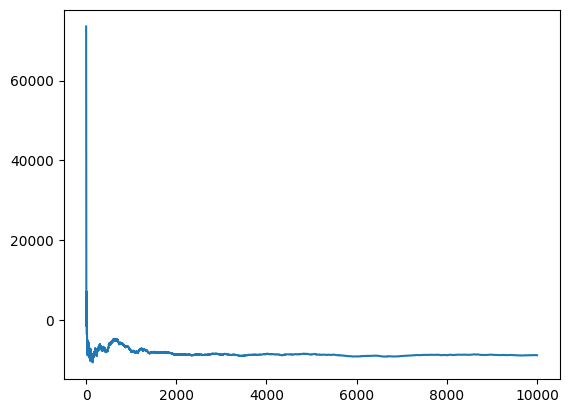

In [ ]:
plt.plot(running_estimate)

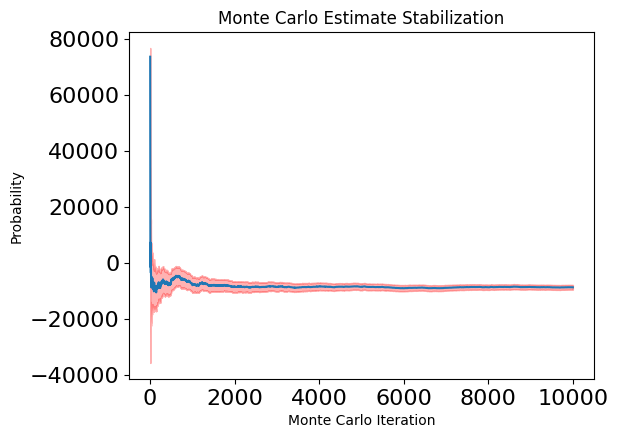

In [ ]:
plt.figure(figsize=(6, 4.5))
plt.plot(running_estimate)
plt.xlabel("Monte Carlo Iteration")
plt.ylabel("Probability")
plt.fill_between(range(nsamp), running_estimate - 1.96 * std_mc_out, running_estimate + 1.96 * std_mc_out, color='red', alpha=0.3)
plt.tick_params(labelsize=16)
plt.title("Monte Carlo Estimate Stabilization")
# plt.ylim(0, 0.04)
plt.show()

In [ ]:
running_estimate

array([           nan, 73559.56756701, 49853.51245208, ...,
       -8790.19811923, -8797.76263216, -8800.911879  ], shape=(10000,))